In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import wave
import pylab
import itertools
import librosa 
import librosa.display as ld
from tensorflow.keras import layers, models, callbacks
from keras.utils import plot_model
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy import signal
from scipy.io import wavfile

2026-05-01 11:09:32.628992: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-01 11:09:32.629018: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-01 11:09:32.629043: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-01 11:09:32.634989: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("warcoder/cats-vs-dogs-vs-birds-audio-classification")

print("Path to dataset files:", path)

Path to dataset files: /home/nikita/.cache/kagglehub/datasets/warcoder/cats-vs-dogs-vs-birds-audio-classification/versions/1


In [3]:
file = os.listdir(path)
files_in_dir = os.listdir(path + '/' + file[0])

print(files_in_dir)

path_to_files = path + '/' + file[0]

['cat', 'dog', 'bird']


In [4]:
num_wav_files = []
for subdir in files_in_dir:
    subdir_path = os.path.join(path_to_files, subdir)
    wav_files = [file for file in os.listdir(subdir_path) if file.endswith('.wav')]
    num_wav_files.append(len(wav_files))

for i, cl in enumerate(files_in_dir):
    print(f'файлов в части {cl} :', num_wav_files[i])

файлов в части cat : 207
файлов в части dog : 210
файлов в части bird : 193


In [5]:
#https://habr.com/ru/companies/otus/articles/741080/

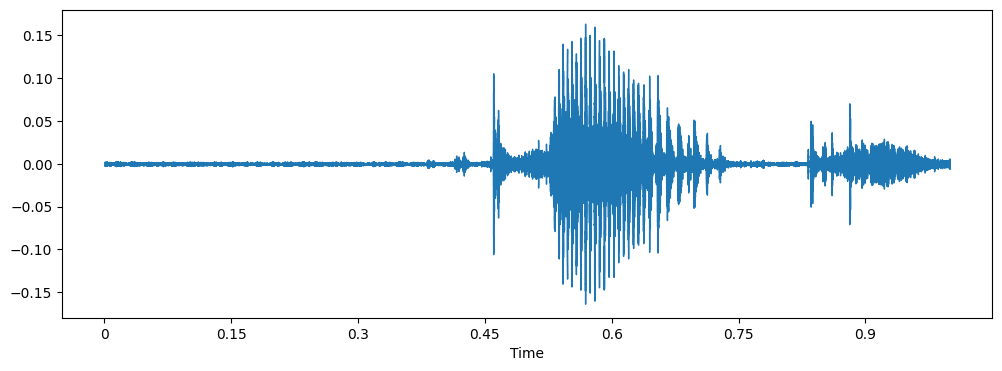

In [6]:
for subdir in [files_in_dir[0]]:
    subdir_path = os.path.join(path_to_files, subdir)
    wav_files = [file for file in os.listdir(subdir_path) if file.endswith('.wav')]

    for i in range(1):
        file_path = os.path.join(subdir_path, wav_files[i])
        signal, sr = librosa.load(file_path, sr = 22050)

        plt.figure(figsize=(12,4))
        ld.waveshow(signal, sr=sr)
        plt.show()
        

In [7]:
import IPython
display(IPython.display.Audio(signal, rate = sr))

Text(0, 0.5, 'Amplitude')

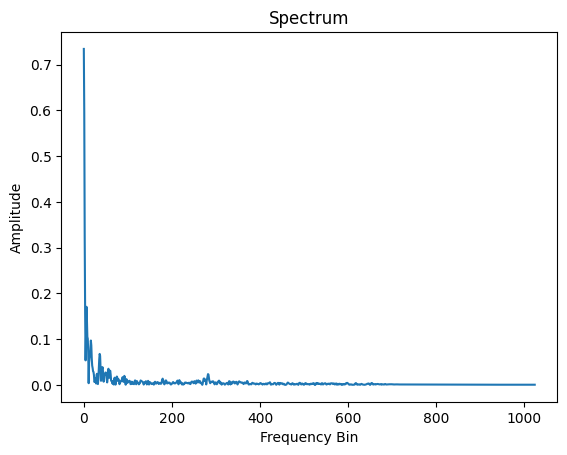

In [8]:
n_fft = 2048
ft = np.abs(librosa.stft(signal[:n_fft], hop_length = n_fft+1))
plt.plot(ft)
plt.title('Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')

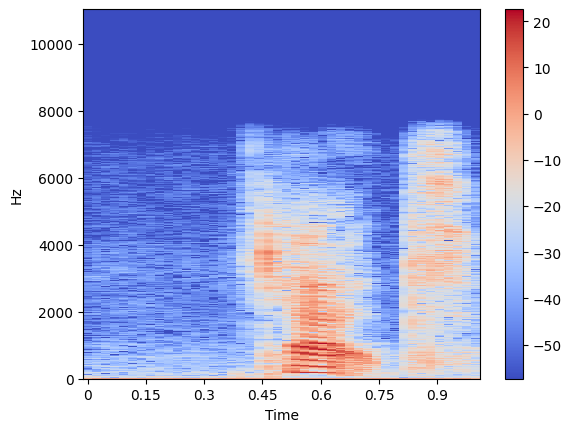

In [9]:
X = librosa.stft(signal)
s = librosa.amplitude_to_db(abs(X))
ld.specshow(s, sr=sr, x_axis = 'time', y_axis='linear')
plt.colorbar()

In [10]:
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc = 40, hop_length=512)
mfccs

array([[-6.1517200e+02, -5.9403461e+02, -5.9030829e+02, ...,
        -3.6716949e+02, -4.0643671e+02, -4.6905157e+02],
       [ 9.6003242e+01,  1.0062929e+02,  1.0466718e+02, ...,
         6.6065628e+01,  8.9983536e+01,  1.0900162e+02],
       [ 1.2745180e+01,  5.9425225e+00,  2.1231849e+00, ...,
        -6.4588676e+01, -5.6294777e+01, -4.0392250e+01],
       ...,
       [ 2.4171531e+00,  2.0527802e+00,  2.8669603e+00, ...,
        -1.4882596e+00,  4.5297384e+00,  8.7978268e+00],
       [-6.8465614e-01, -4.4043040e+00, -9.9083215e-01, ...,
        -3.9643302e+00, -5.1668086e+00,  1.5527653e+00],
       [-1.4325167e+00, -1.5794814e+00,  3.0769959e-01, ...,
         1.6648782e+00, -2.0170474e+00,  8.5016823e-01]], dtype=float32)

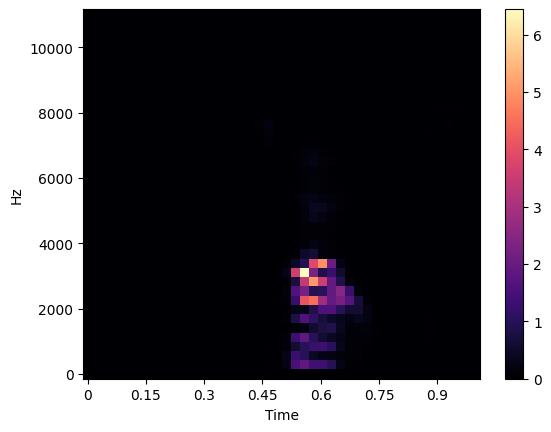

In [11]:
melspectrum = librosa.feature.melspectrogram(y=signal, sr = sr,hop_length =512, n_mels = 40)
ld.specshow(melspectrum, sr=sr, x_axis = 'time', y_axis='linear')
plt.colorbar()

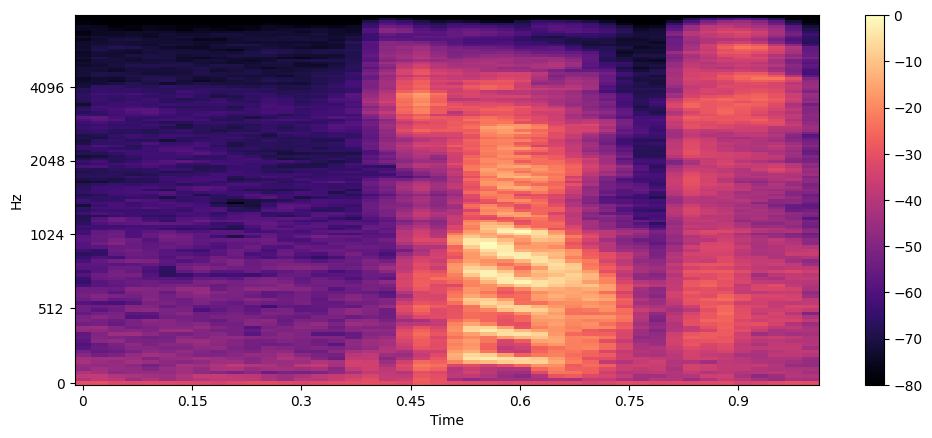

In [12]:
S = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sr, fmax=8000)
plt.colorbar()

In [13]:
#аугментация
#https://medium.com/@joshiprerak123/supercharge-your-audio-mastering-sound-with-audiomentations-for-creative-augmentation-0dec7c9f010e

In [14]:
from audiomentations import Reverse
from audiomentations import PitchShift
from audiomentations import BitCrush

data = []
labels = []

sr = 17000
transform_r = Reverse(p=1.0)
transform_p = PitchShift(min_semitones=-5.0, max_semitones=5.0, p=1.0)
transform_b = BitCrush(min_bit_depth=8, max_bit_depth=14, p=1.0)

for k, subdir in enumerate(files_in_dir):
    subdir_path = os.path.join(path_to_files, subdir)
    wav_files = [file for file in os.listdir(subdir_path) if file.endswith('.wav')]

    for i in range(len(wav_files)):
        file_path = os.path.join(subdir_path, wav_files[i])
        signal, sr = librosa.load(file_path)
        dorojka = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc = 40, hop_length=512)
        data.append(np.mean(dorojka, axis = 1))
        labels.append(k)
        
        augmented_reverse = transform_r(signal, sample_rate=sr)
        dorojka_r = librosa.feature.mfcc(y=augmented_reverse, n_mfcc = 40, hop_length=512)
        data.append(np.mean(dorojka_r, axis = 1))
        labels.append(k)

        augmented_p = transform_p(signal, sample_rate=sr)
        dorojka_p = librosa.feature.mfcc(y=augmented_p, n_mfcc = 40, hop_length=512)
        data.append(np.mean(dorojka_p, axis = 1))
        labels.append(k)

        augmented_b = transform_b(signal, sample_rate=sr)
        dorojka_b = librosa.feature.mfcc(y=augmented_b, n_mfcc = 40, hop_length=512)
        data.append(np.mean(dorojka_b, axis = 1))
        labels.append(k)

In [15]:
data = np.array(data)
labels = np.array(labels)

In [16]:
from sklearn.model_selection import train_test_split

X = data
y = labels

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=True, stratify=y)

In [18]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_leaf=5)
clf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
print('точность для обучающей выборки:', round(clf.score(x_train, y_train), 2), 'точность для тестовой выборки:', round(clf.score(x_test, y_test), 2))

точность для обучающей выборки: 0.99 точность для тестовой выборки: 0.91
